<a href="https://colab.research.google.com/github/naiaramr/-Atividade-Avaliativa-Progama-o/blob/main/AdminAn%C3%A1liseA%C3%A7%C3%B5es.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise do Código de Referência - Petrobrás (PETR4)

## Visão Geral

Este código implementa uma análise financeira completa da ação da Petrobrás (PETR4.SA) para o período de **janeiro de 2023 a maio de 2026**. O script demonstra todas as etapas necessárias para baixar, processar, analisar e visualizar dados históricos de ações, servindo como referência para a análise das demais empresas.



📥 Baixando dados da PETR4.SA de 2023-01-01 até 2026-05-14...
✅ Dados carregados! Shape: (838, 5)
Colunas disponíveis: [('Close', 'PETR4.SA'), ('High', 'PETR4.SA'), ('Low', 'PETR4.SA'), ('Open', 'PETR4.SA'), ('Volume', 'PETR4.SA')]
Período: 2023-01-02 até 2026-05-13

📋 5 PRIMEIRAS LINHAS
            Abertura  Máxima  Mínima  Fechamento     Volume
Date                                                       
2023-01-02     12.80   13.29   12.73       13.14   78424700
2023-01-03     12.47   12.90   12.36       12.81   96750300
2023-01-04     12.87   13.17   12.19       12.26  129504000
2023-01-05     13.33   13.42   12.92       13.03   73886000
2023-01-06     13.25   13.58   13.15       13.37   51851500

📋 5 ÚLTIMAS LINHAS
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     46.22   46.65   45.20       46.40  71214500
2026-05-08     45.67   46.55   45.67       46.39  32914200
2026-05-11     46.43   46.51   45.65

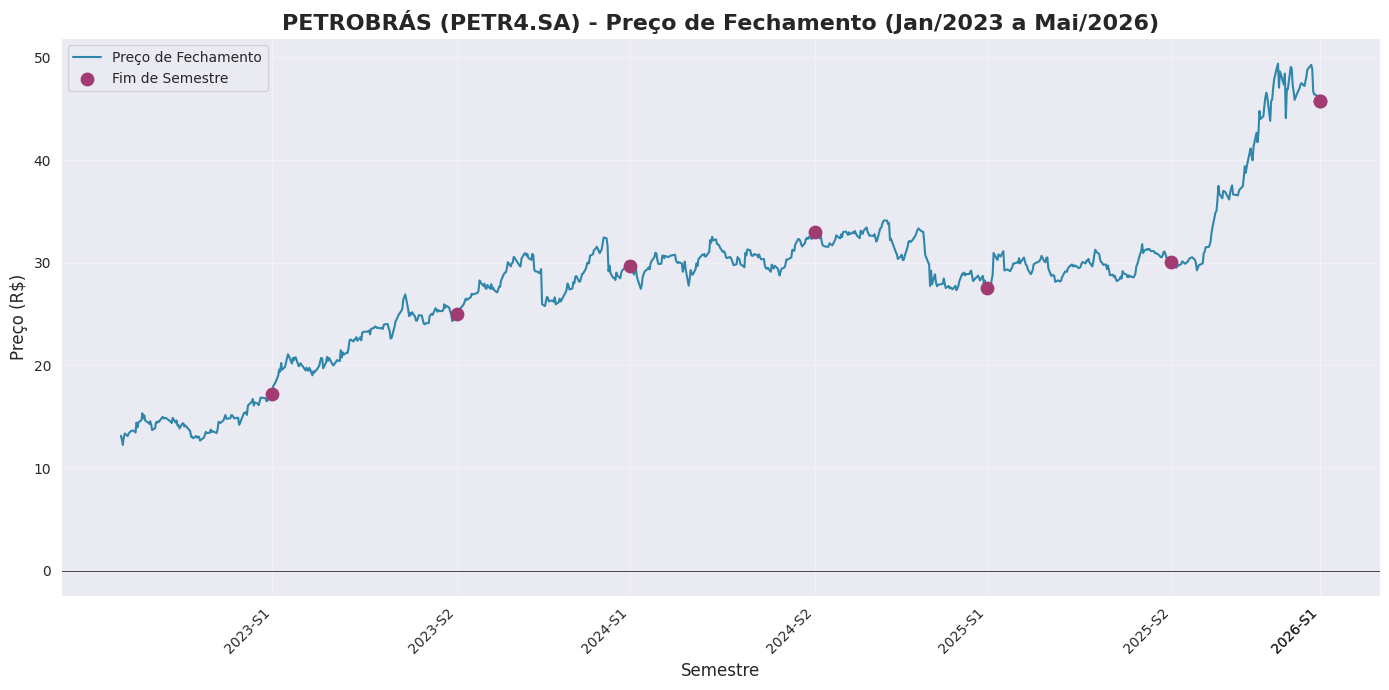


📊 TABELA RESUMO SEMESTRAL
 Ano Semestre  Abertura_R$  Fechamento_R$  Média_R$  Desvio_R$  Mínimo_R$  Máximo_R$  Retorno_%
2023       S1        13.14          20.77     15.28       2.21      12.26      21.08      58.06
2023       S2        19.91          26.91     23.21       2.25      19.04      26.98      35.14
2024       S1        27.07          30.16     28.84       1.54      25.79      32.46      11.44
2024       S2        30.57          31.70     30.71       1.10      27.77      33.11       3.69
2025       S1        32.26          29.18     30.71       2.17      27.32      34.13      -9.54
2025       S2        29.41          30.38     29.80       0.85      28.15      31.81       3.32
2026       S1        30.54          45.77     40.98       6.39      29.27      49.39      49.86

🎉 ANÁLISE CONCLUÍDA COM SUCESSO!

📈 RESUMO FINAL DO PERÍODO
Preço Inicial (jan/2023): R$ 13.14
Preço Final (mai/2026): R$ 45.77
Retorno Total no período: +248.26%
Volume Médio Diário: 43,917,718 ações


In [3]:
# =====================================================
# ANÁLISE DA PETROBRÁS (PETR4) - JAN/2023 ATÉ MAI/2026
# =====================================================

!pip install yfinance pandas matplotlib seaborn -q

import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (14, 7)

# ================== 1. BAIXAR DADOS ==================
ticker = "PETR4.SA"
start_date = "2023-01-01"
end_date = "2026-05-14"

print(f"📥 Baixando dados da {ticker} de {start_date} até {end_date}...")

df_petro = yf.download(ticker, start=start_date, end=end_date, progress=False)

print(f"✅ Dados carregados! Shape: {df_petro.shape}")
print(f"Colunas disponíveis: {list(df_petro.columns)}")

# Renomear colunas para português (apenas 5 colunas)
df_petro.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

print(f"Período: {df_petro.index.min().date()} até {df_petro.index.max().date()}")

# ================== 2. 5 PRIMEIRAS E 5 ÚLTIMAS LINHAS ==================
print("\n" + "="*80)
print("📋 5 PRIMEIRAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].head().round(2))

print("\n" + "="*80)
print("📋 5 ÚLTIMAS LINHAS")
print("="*80)
print(df_petro[['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']].tail().round(2))

# ================== 3. MÉDIA ANUAL DO PREÇO DE FECHAMENTO ==================
df_petro['Ano'] = df_petro.index.year
media_anual = df_petro.groupby('Ano')['Fechamento'].mean()

print("\n" + "="*80)
print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, media in media_anual.items():
    print(f"{ano}: R$ {media:.2f}")

# ================== 4. DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO ==================
std_anual = df_petro.groupby('Ano')['Fechamento'].std()

print("\n" + "="*80)
print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
print("="*80)
for ano, std in std_anual.items():
    print(f"{ano}: R$ {std:.2f}")

# ================== 5. RETORNO SEMESTRAL ==================
# Adicionar coluna de semestre
df_petro['Semestre'] = df_petro.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
df_petro['Ano_Semestre'] = df_petro['Ano'].astype(str) + '_' + df_petro['Semestre']

# Calcular retorno semestral (primeiro vs último dia de cada semestre)
print("\n" + "="*80)
print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
print("="*80)

# Obter último dia de cada semestre
ultimo_dia_semestre = df_petro.groupby('Ano_Semestre').apply(lambda x: x.index.max())
retornos_semestrais = []

for i in range(len(ultimo_dia_semestre) - 1):
    sem_atual = ultimo_dia_semestre.index[i]
    sem_seguinte = ultimo_dia_semestre.index[i+1]

    fechamento_atual = df_petro.loc[ultimo_dia_semestre[i], 'Fechamento']
    fechamento_seguinte = df_petro.loc[ultimo_dia_semestre[i+1], 'Fechamento']

    retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
    sinal = "+" if retorno >= 0 else ""
    print(f"{sem_atual} → {sem_seguinte}: {sinal}{retorno:.2f}%")

    retornos_semestrais.append({
        'Período': f"{sem_atual} → {sem_seguinte}",
        'Retorno_%': retorno
    })

# ================== 6. GRÁFICO DE LINHA COM EIXO X SEMESTRAL ==================
# Criar pontos para cada semestre (último dia útil de cada semestre)
pontos_semestrais = []
labels_semestrais = []

# Definir os meses de fim de semestre: Junho (S1) e Dezembro (S2)
for ano in range(2023, 2027):
    for sem, mes in [('S1', 6), ('S2', 12)]:
        try:
            # Tentar pegar o último dia do mês (junho ou dezembro)
            data_alvo = pd.Timestamp(f"{ano}-{mes}-{mes}")
            # Buscar o maior índice <= data_alvo
            dados_semestre = df_petro[df_petro.index <= data_alvo]
            if not dados_semestre.empty:
                ultima_data = dados_semestre.index[-1]
                pontos_semestrais.append(ultima_data)
                labels_semestrais.append(f"{ano}-{sem}")
        except:
            pass

# Filtrar apenas pontos até maio/2026
pontos_semestrais = [p for p in pontos_semestrais if p <= pd.Timestamp("2026-05-14")]

# Criar o gráfico
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df_petro.index, df_petro['Fechamento'], linewidth=1.5, color='#2E86AB', label='Preço de Fechamento')

# Destacar pontos semestrais
if pontos_semestrais:
    valores_semestrais = df_petro.loc[pontos_semestrais, 'Fechamento']
    ax.scatter(pontos_semestrais, valores_semestrais, color='#A23B72', s=80, zorder=5, label='Fim de Semestre')

# Configurar eixo X com semestres
if pontos_semestrais:
    ax.set_xticks(pontos_semestrais)
    ax.set_xticklabels([f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos_semestrais],
                       rotation=45, ha='right')

ax.set_title('PETROBRÁS (PETR4.SA) - Preço de Fechamento (Jan/2023 a Mai/2026)', fontsize=16, fontweight='bold')
ax.set_xlabel('Semestre', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)
ax.axhline(y=0, color='black', linewidth=0.5)

plt.tight_layout()
plt.show()

# ================== 7. TABELA RESUMO SEMESTRAL ==================
print("\n" + "="*80)
print("📊 TABELA RESUMO SEMESTRAL")
print("="*80)

# Função para obter último dia de cada semestre
def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")

    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        ultima_data = dados_sem.index[-1]
        return ultima_data
    return None

tabela_semestral = []
for ano in range(2023, 2027):
    for sem in ['S1', 'S2']:
        ultima_data = get_ultimo_dia_semestre(df_petro, ano, sem)
        if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
            dados_sem = df_petro[df_petro.index.year == ano]
            if sem == 'S1':
                dados_sem = dados_sem[dados_sem.index.month <= 6]
            else:
                dados_sem = dados_sem[dados_sem.index.month > 6]

            if not dados_sem.empty:
                abertura = dados_sem['Fechamento'].iloc[0]
                fechamento = dados_sem['Fechamento'].iloc[-1]
                media = dados_sem['Fechamento'].mean()
                desvio = dados_sem['Fechamento'].std()
                minimo = dados_sem['Fechamento'].min()
                maximo = dados_sem['Fechamento'].max()
                retorno = ((fechamento - abertura) / abertura) * 100

                tabela_semestral.append({
                    'Ano': ano,
                    'Semestre': sem,
                    'Abertura_R$': abertura,
                    'Fechamento_R$': fechamento,
                    'Média_R$': media,
                    'Desvio_R$': desvio,
                    'Mínimo_R$': minimo,
                    'Máximo_R$': maximo,
                    'Retorno_%': retorno
                })

df_tabela = pd.DataFrame(tabela_semestral)
print(df_tabela.to_string(index=False, float_format="%.2f"))

print("\n" + "="*80)
print("🎉 ANÁLISE CONCLUÍDA COM SUCESSO!")
print("="*80)

# Estatísticas adicionais finais
print("\n" + "="*80)
print("📈 RESUMO FINAL DO PERÍODO")
print("="*80)
preco_inicial = df_petro['Fechamento'].iloc[0]
preco_final = df_petro['Fechamento'].iloc[-1]
retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
print(f"Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
print(f"Preço Final (mai/2026): R$ {preco_final:.2f}")
print(f"Retorno Total no período: {retorno_total:+.2f}%")
print(f"Volume Médio Diário: {df_petro['Volume'].mean():,.0f} ações")

# EXERCÍCIO: ANÁLISE COMPARATIVA DE AÇÕES BRASILEIRAS

## Contexto

Você é um analista financeiro e precisa avaliar o desempenho de 4 importantes empresas brasileiras no período de **janeiro de 2023 até 14 de maio de 2026**. As empresas e seus respectivos tickers são:

| Empresa | Ticker (Yahoo Finance) |
|---------|------------------------|
| Vale S.A. | VALE3.SA |
| Ambev S.A. | ABEV3.SA |
| Itaú Unibanco | ITUB4.SA |
| Banco do Brasil | BBAS3.SA |

## Objetivo

Para **cada uma das 4 empresas**, você deverá realizar as seguintes tarefas:

1. **Baixar os dados históricos** das ações no período solicitado utilizando a biblioteca `yfinance`

2. **Exibir as 5 primeiras e 5 últimas linhas** do DataFrame resultante (apenas as colunas de preços e volume)

3. **Calcular e exibir a média anual do preço de fechamento** para cada ano do período (2023, 2024, 2025 e 2026*)

4. **Calcular e exibir o desvio-padrão anual do preço de fechamento** para cada ano do período

5. **Calcular e exibir o retorno semestral** do preço de fechamento, mostrando a variação percentual entre semestres consecutivos (ex: 2023-S1 → 2023-S2, 2023-S2 → 2024-S1, etc.)

6. **Gerar um gráfico de linha do preço de fechamento** no período completo, com o eixo X rotulado apenas pelos semestres (ex: 2023-S1, 2023-S2, 2024-S1, etc.)


  📊 ANÁLISE: Vale S.A. (VALE3.SA)

📥 Baixando dados de VALE3.SA...
✅ Dados carregados! Shape: (838, 5)
Período: 2023-01-02 até 2026-05-13

────────────────────────────────────────────────────────────
📋 5 PRIMEIRAS LINHAS
────────────────────────────────────────────────────────────
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2023-01-02     66.08   66.99   65.97       66.62  12783800
2023-01-03     66.62   67.13   66.24       66.50  25332600
2023-01-04     66.54   66.80   65.54       66.62  26395300
2023-01-05     66.66   68.32   66.32       67.73  29085600
2023-01-06     67.81   69.11   67.81       68.81  31420600

────────────────────────────────────────────────────────────
📋 5 ÚLTIMAS LINHAS
────────────────────────────────────────────────────────────
            Abertura  Máxima  Mínima  Fechamento    Volume
Date                                                      
2026-05-07     81.29   81.67   79.60       8

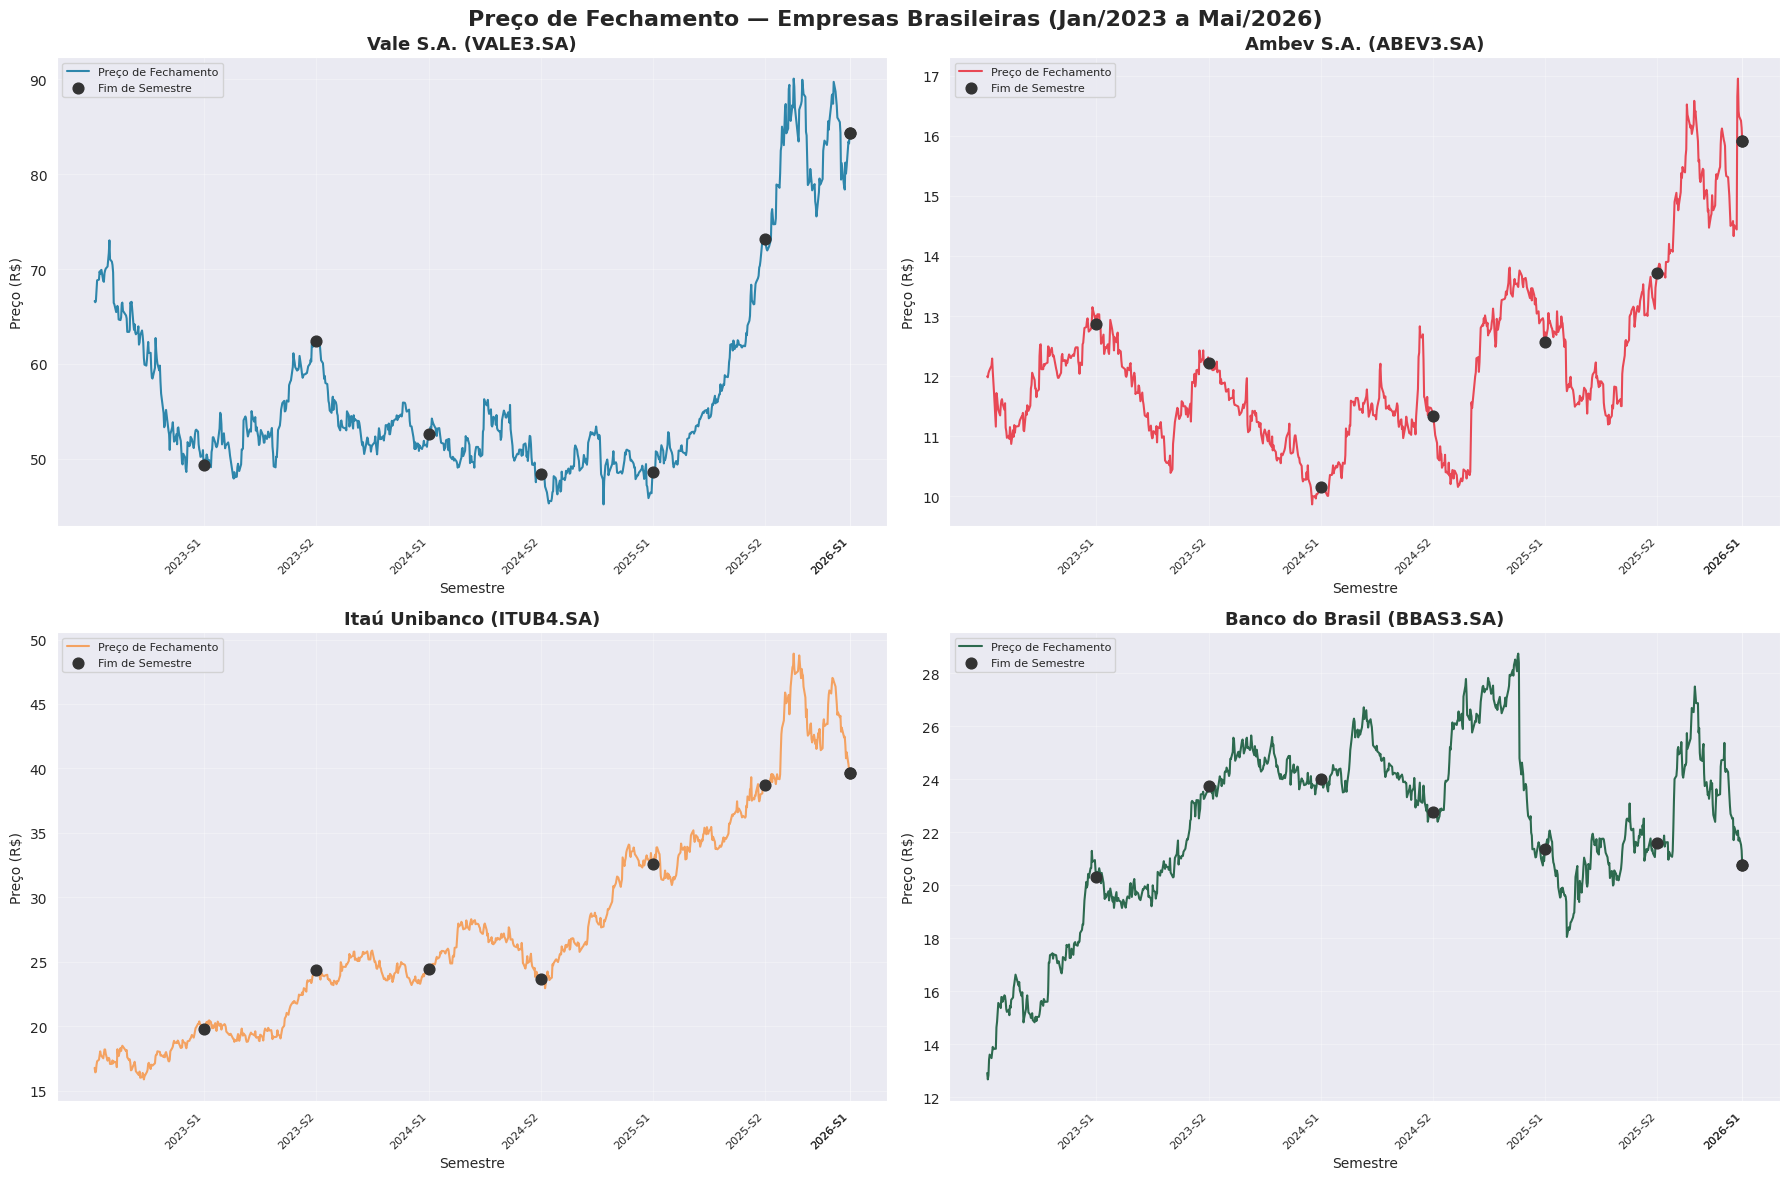

In [7]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')

sns.set_style("darkgrid")

# ================== CONFIGURAÇÕES ==================
empresas = {
    "VALE3.SA": "Vale S.A.",
    "ABEV3.SA": "Ambev S.A.",
    "ITUB4.SA": "Itaú Unibanco",
    "BBAS3.SA": "Banco do Brasil"
}

cores = {
    "VALE3.SA": "#2E86AB",
    "ABEV3.SA": "#E84855",
    "ITUB4.SA": "#F4A261",
    "BBAS3.SA": "#2D6A4F"
}

start_date = "2023-01-01"
end_date = "2026-05-14"

# ================== FUNÇÕES AUXILIARES ==================

def get_ultimo_dia_semestre(df, ano, semestre):
    if semestre == 'S1':
        data_fim = pd.Timestamp(f"{ano}-06-30")
    else:
        data_fim = pd.Timestamp(f"{ano}-12-31")
    dados_sem = df[df.index <= data_fim]
    if not dados_sem.empty:
        return dados_sem.index[-1]
    return None


def calcular_retornos_semestrais(df):
    df = df.copy()
    df['Ano'] = df.index.year
    df['Semestre'] = df.index.quarter.map({1: 'S1', 2: 'S1', 3: 'S2', 4: 'S2'})
    df['Ano_Semestre'] = df['Ano'].astype(str) + '_' + df['Semestre']

    ultimo_dia_semestre = df.groupby('Ano_Semestre').apply(lambda x: x.index.max())
    retornos = []

    for i in range(len(ultimo_dia_semestre) - 1):
        sem_atual = ultimo_dia_semestre.index[i]
        sem_seguinte = ultimo_dia_semestre.index[i + 1]
        fechamento_atual = df.loc[ultimo_dia_semestre[i], 'Fechamento']
        fechamento_seguinte = df.loc[ultimo_dia_semestre[i + 1], 'Fechamento']
        retorno = ((fechamento_seguinte - fechamento_atual) / fechamento_atual) * 100
        retornos.append((sem_atual, sem_seguinte, retorno))

    return retornos


def pontos_eixo_x_semestral(df):
    pontos = []
    for ano in range(2023, 2027):
        for sem, mes in [('S1', 6), ('S2', 12)]:
            try:
                data_alvo = pd.Timestamp(f"{ano}-{mes:02d}-28")
                dados = df[df.index <= data_alvo]
                if not dados.empty:
                    ultima = dados.index[-1]
                    if ultima <= pd.Timestamp("2026-05-14"):
                        pontos.append(ultima)
            except:
                pass
    return pontos


def gerar_tabela_semestral(df):
    tabela = []
    for ano in range(2023, 2027):
        for sem in ['S1', 'S2']:
            ultima_data = get_ultimo_dia_semestre(df, ano, sem)
            if ultima_data and ultima_data <= pd.Timestamp("2026-05-14"):
                dados_sem = df[df.index.year == ano]
                if sem == 'S1':
                    dados_sem = dados_sem[dados_sem.index.month <= 6]
                else:
                    dados_sem = dados_sem[dados_sem.index.month > 6]
                if not dados_sem.empty:
                    abertura = dados_sem['Fechamento'].iloc[0]
                    fechamento = dados_sem['Fechamento'].iloc[-1]
                    retorno = ((fechamento - abertura) / abertura) * 100
                    tabela.append({
                        'Ano': ano, 'Semestre': sem,
                        'Abertura_R$': abertura, 'Fechamento_R$': fechamento,
                        'Média_R$': dados_sem['Fechamento'].mean(),
                        'Desvio_R$': dados_sem['Fechamento'].std(),
                        'Mínimo_R$': dados_sem['Fechamento'].min(),
                        'Máximo_R$': dados_sem['Fechamento'].max(),
                        'Retorno_%': retorno
                    })
    return pd.DataFrame(tabela)


# ================== LOOP PRINCIPAL POR EMPRESA ==================
dados_todos = {}

for ticker, nome in empresas.items():
    sep = "=" * 80
    print(f"\n{sep}")
    print(f"  📊 ANÁLISE: {nome} ({ticker})")
    print(sep)

    # 1. BAIXAR DADOS
    print(f"\n📥 Baixando dados de {ticker}...")
    df = yf.download(ticker, start=start_date, end=end_date, progress=False)

    # Tratar MultiIndex se necessário
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)

    # Selecionar apenas as colunas relevantes
    df = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.columns = ['Abertura', 'Máxima', 'Mínima', 'Fechamento', 'Volume']

    print(f"✅ Dados carregados! Shape: {df.shape}")
    print(f"Período: {df.index.min().date()} até {df.index.max().date()}")

    dados_todos[ticker] = df

    # 2. PRIMEIRAS E ÚLTIMAS LINHAS
    print(f"\n{'─'*60}")
    print("📋 5 PRIMEIRAS LINHAS")
    print('─'*60)
    print(df.head().round(2).to_string())

    print(f"\n{'─'*60}")
    print("📋 5 ÚLTIMAS LINHAS")
    print('─'*60)
    print(df.tail().round(2).to_string())

    # 3. MÉDIA ANUAL
    df['Ano'] = df.index.year
    media_anual = df.groupby('Ano')['Fechamento'].mean()
    print(f"\n{'─'*60}")
    print("📊 MÉDIA ANUAL DO PREÇO DE FECHAMENTO (R$)")
    print('─'*60)
    for ano, media in media_anual.items():
        print(f"  {ano}: R$ {media:.2f}")

    # 4. DESVIO-PADRÃO ANUAL
    std_anual = df.groupby('Ano')['Fechamento'].std()
    print(f"\n{'─'*60}")
    print("📊 DESVIO-PADRÃO ANUAL DO PREÇO DE FECHAMENTO (R$)")
    print('─'*60)
    for ano, std in std_anual.items():
        print(f"  {ano}: R$ {std:.2f}")

    # 5. RETORNO SEMESTRAL
    retornos = calcular_retornos_semestrais(df)
    print(f"\n{'─'*60}")
    print("📊 RETORNO SEMESTRAL DO PREÇO DE FECHAMENTO (%)")
    print('─'*60)
    for sem_a, sem_b, ret in retornos:
        sinal = "+" if ret >= 0 else ""
        print(f"  {sem_a} → {sem_b}: {sinal}{ret:.2f}%")

    # 7. TABELA RESUMO SEMESTRAL
    df_tabela = gerar_tabela_semestral(df)
    print(f"\n{'─'*60}")
    print("📊 TABELA RESUMO SEMESTRAL")
    print('─'*60)
    print(df_tabela.to_string(index=False, float_format="%.2f"))

    # RESUMO FINAL
    preco_inicial = df['Fechamento'].iloc[0]
    preco_final = df['Fechamento'].iloc[-1]
    retorno_total = ((preco_final - preco_inicial) / preco_inicial) * 100
    print(f"\n{'─'*60}")
    print(f"📈 RESUMO FINAL DO PERÍODO - {nome}")
    print('─'*60)
    print(f"  Preço Inicial (jan/2023): R$ {preco_inicial:.2f}")
    print(f"  Preço Final (mai/2026):   R$ {preco_final:.2f}")
    print(f"  Retorno Total no período: {retorno_total:+.2f}%")
    print(f"  Volume Médio Diário:      {df['Volume'].mean():,.0f} ações")

# ================== 6. GRÁFICOS DE LINHA (4 subplots) ==================
print(f"\n{'='*80}")
print("📈 GERANDO GRÁFICOS DE LINHA...")
print('='*80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Preço de Fechamento — Empresas Brasileiras (Jan/2023 a Mai/2026)',
             fontsize=16, fontweight='bold', y=0.98)

for ax, (ticker, nome) in zip(axes.flatten(), empresas.items()):
    df = dados_todos[ticker]
    cor = cores[ticker]

    pontos = pontos_eixo_x_semestral(df)

    ax.plot(df.index, df['Fechamento'], linewidth=1.5, color=cor, label='Preço de Fechamento')

    if pontos:
        valores = df.loc[pontos, 'Fechamento']
        ax.scatter(pontos, valores, color='#333333', s=60, zorder=5, label='Fim de Semestre')
        ax.set_xticks(pontos)
        ax.set_xticklabels(
            [f"{p.year}-{'S1' if p.month <= 6 else 'S2'}" for p in pontos],
            rotation=45, ha='right', fontsize=8
        )

    ax.set_title(f'{nome} ({ticker})', fontsize=13, fontweight='bold')
    ax.set_xlabel('Semestre', fontsize=10)
    ax.set_ylabel('Preço (R$)', fontsize=10)
    ax.legend(loc='upper left', fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()

output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)
plt.savefig(output_dir + 'grafico_empresas_brasileiras.png', dpi=150, bbox_inches='tight')
plt.show()
